<h2 style="color:#9D2449; font-family:'Montserrat', sans-serif; font-size:42px; font-weight:700; margin-top:25px; margin-bottom:12px;">
Índice de Esfuerzo Ciudadano
</h2>

<h4 style="color:#B38E5D; font-family:'Montserrat', sans-serif; font-size:22px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Metodología II: Ponderación por Eigenvalores
</h4>

<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Carga de Datos
</h4>

In [13]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
import numpy as np

In [3]:
path = "https://raw.githubusercontent.com/gonza98kg/Tramites-y-servicios/eigenvalue-weighted-index/df_exp2.csv"
df = pd.read_csv(path)

df.head()

,Idtram,Tramite,Secretaria,Dependencia,Domicilio,TraPersona,Tiempo_en_minutos,N_FORMATOS_FINAL,CONTEO_NETO,nivel_digitalizacion,TraResolucionesFavorables,TraResolucionesNegativas,Porcentaje_Efectividad,TraCosto,visitas_totales,Visitas RUTS,Indice_Esfuerzo_A
0,7679.0,Transporte Público Masivo de Pasajeros Tuzobús.,Secretaría de Movilidad y Transporte,Sistema de Transporte Masivo de Hidalgo,Calle s/n Venta Prieta 42083 Pachuca De Soto P...,Social,5.00000,0,1,1,21096550,0,100.0,1,454.00000,3852.000000,-1.432411
1,1743.0,Impuesto sobre Tenencia y Refrendo Vehicular (...,Secretaría de Hacienda,Secretaría de Hacienda,Calle No. 1 Centro 42500 Pachuca De Soto Pachu...,Ambos,10.00000,2,8,12,368871,0,100.0,1,39912.00000,81886.000000,9.619706
2,9229.0,Canje de Placas,Secretaría de Hacienda,Secretaría de Hacienda,Calle 801 Canutillo 42060 Pachuca De Soto Pach...,Ambos,20.00000,3,10,1,423743,0,100.0,1,5168.00000,82305.000000,-1.284045
3,533.0,Servicio de laboratorio clínico en el Hospital...,Organismos No Sectorizados,Sistema para el Desarrollo Integral de la Fami...,Boulevard s/n Venta Prieta 42083 Pachuca De So...,Social,22864.51619,0,2,1,620,0,100.0,0,667.00000,3305.417936,-1.537264
4,10885.0,Cambio de Propietario,Secretaría de Hacienda,Secretaría de Hacienda,Calle 1 Centro 42500 Actopan Actopan,Ambos,1440.00000,2,7,1,88932,0,100.0,1,2871.06701,25387.000000,-1.339720


<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Datos de Entrada
</h4>

Se parte del DataFrame df_exp2, generado en la rama PCA-and-correlation-analysis como resultado del preprocesamiento aplicado sobre la base original de 666 trámites y servicios del estado de Hidalgo. Este DataFrame cuenta con 665 registros tras la eliminación del único registro con Idtram nulo, y con los valores faltantes en variables numéricas imputados con la media y en variables categóricas con la moda.

A diferencia de df_exp1 —que aplicó One Hot Encoding sobre nivel_digitalizacion perdiendo la jerarquía ordinal entre niveles— y de df_esc_A —que aplica RobustScaler produciendo valores negativos incompatibles con un índice en escala [0, 100]—, df_exp2 conserva la variable nivel_digitalizacion con codificación ordinal (Nivel 1 → 1, ..., Nivel 4.3 → 14), preservando la estructura jerárquica de los niveles de digitalización, y mantiene las variables en su escala original, lo que permite aplicar sobre ellas las funciones de sub-índices de normalización a [0, 100] definidas en la metodología de combinación lineal ponderada.

Se elimina la columna "Indice_Esfuerzo_A" ya que esta es heredada de la metodología del PCA, ya que no aporta nada, puede confundirse con la variable objetivo que se quiere crear mediante la combinación lineal. 

In [4]:
df = df.drop(columns=['Indice_Esfuerzo_A'])
df.head()

,Idtram,Tramite,Secretaria,Dependencia,Domicilio,TraPersona,Tiempo_en_minutos,N_FORMATOS_FINAL,CONTEO_NETO,nivel_digitalizacion,TraResolucionesFavorables,TraResolucionesNegativas,Porcentaje_Efectividad,TraCosto,visitas_totales,Visitas RUTS
0,7679.0,Transporte Público Masivo de Pasajeros Tuzobús.,Secretaría de Movilidad y Transporte,Sistema de Transporte Masivo de Hidalgo,Calle s/n Venta Prieta 42083 Pachuca De Soto P...,Social,5.00000,0,1,1,21096550,0,100.0,1,454.00000,3852.000000
1,1743.0,Impuesto sobre Tenencia y Refrendo Vehicular (...,Secretaría de Hacienda,Secretaría de Hacienda,Calle No. 1 Centro 42500 Pachuca De Soto Pachu...,Ambos,10.00000,2,8,12,368871,0,100.0,1,39912.00000,81886.000000
2,9229.0,Canje de Placas,Secretaría de Hacienda,Secretaría de Hacienda,Calle 801 Canutillo 42060 Pachuca De Soto Pach...,Ambos,20.00000,3,10,1,423743,0,100.0,1,5168.00000,82305.000000
3,533.0,Servicio de laboratorio clínico en el Hospital...,Organismos No Sectorizados,Sistema para el Desarrollo Integral de la Fami...,Boulevard s/n Venta Prieta 42083 Pachuca De So...,Social,22864.51619,0,2,1,620,0,100.0,0,667.00000,3305.417936
4,10885.0,Cambio de Propietario,Secretaría de Hacienda,Secretaría de Hacienda,Calle 1 Centro 42500 Actopan Actopan,Ambos,1440.00000,2,7,1,88932,0,100.0,1,2871.06701,25387.000000


In [5]:
df.dtypes

Idtram                       float64
Tramite                       object
Secretaria                    object
Dependencia                   object
Domicilio                     object
TraPersona                    object
Tiempo_en_minutos            float64
N_FORMATOS_FINAL               int64
CONTEO_NETO                    int64
nivel_digitalizacion           int64
TraResolucionesFavorables      int64
TraResolucionesNegativas       int64
Porcentaje_Efectividad       float64
TraCosto                       int64
visitas_totales              float64
Visitas RUTS                 float64
dtype: object

In [6]:
df.describe().round(2)

,Idtram,Tiempo_en_minutos,N_FORMATOS_FINAL,CONTEO_NETO,nivel_digitalizacion,TraResolucionesFavorables,TraResolucionesNegativas,Porcentaje_Efectividad,TraCosto,visitas_totales,Visitas RUTS
count,665.00,665.00,665.00,665.00,665.00,665.00,665.00,665.00,665.00,665.00,665.00
mean,4522.08,22864.52,0.69,2.34,2.53,39256.66,77.15,76.32,0.70,2871.07,3305.42
std,3867.26,58577.57,0.90,2.47,3.23,818348.18,1223.83,40.66,0.46,16090.43,12390.96
min,332.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,2.00,0.00
25%,1065.00,45.00,0.00,1.00,1.00,3.00,0.00,66.67,0.00,451.00,223.00
50%,1701.00,4320.00,1.00,2.00,1.00,125.00,0.00,100.00,1.00,795.00,650.00
75%,7973.00,22864.52,1.00,3.00,2.00,1347.00,0.00,100.00,1.00,2665.00,2793.00
max,11334.00,518400.00,12.00,15.00,14.00,21096550.00,30151.00,100.00,1.00,374832.00,176203.00


<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Pesos del Índice de Esfuerzo Ciudadano
</h4>

Los pesos $w_i$ de cada variable se derivan de los eigenvalores $\lambda_i$ de la **matriz de correlación de Pearson** $\mathbb{C}$, construida sobre `df_esc_A` (datos escalados con RobustScaler). Dado que las variables son estadísticamente independientes entre sí —confirmado por la alineación 1:1 de cada componente principal con una única variable—, cada eigenvalor cuantifica directamente la varianza estandarizada de su variable asociada. Al normalizar respecto a la suma total ($\sum \lambda_i = 5$), se obtienen pesos fundamentados en la estructura de los datos, eliminando la subjetividad de la metodología anterior.

$$w_i = \frac{\lambda_i}{\sum_{j=1}^{5} \lambda_j}$$

| Variable | Sub-índice | $\lambda_i$ | $w_i$ |
|---|---|:---:|:---:|
| `nivel_digitalizacion` | $I_{Digital}$ | 1.4711 | **29.42%** |
| `Tiempo_en_minutos` | $I_{Tiempo}$ | 1.1132 | **22.26%** |
| `CONTEO_NETO` | $I_{Requisitos}$ | 1.0015 | **20.03%** |
| `N_FORMATOS_FINAL` | $I_{Formatos}$ | 0.8391 | **16.78%** |
| `TraCosto` | $I_{Costo}$ | 0.5750 | **11.50%** |

El IEC resultante es:

$$IEC = 0.2942\cdot I_{Digital} + 0.2226\cdot I_{Tiempo} + 0.2003\cdot I_{Requisitos} + 0.1678\cdot I_{Formatos} + 0.1150\cdot I_{Costo}$$


<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Cálculo de Sub-índices e IEC
</h4>

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Sub-índices
</h4>

Se aplican las mismas funciones de normalización [0, 100] definidas en la Metodología I, ahora ponderadas con los pesos derivados de los eigenvalores de la matriz de correlación.

In [7]:
# ── Sub-índices ──────────────────────────────────────────────────────────────

def calcular_I_Tiempo(t):
    if pd.isna(t) or t < 0:
        return None
    lim_rapido  = 295
    lim_lento   = 9357
    lim_critico = 238115
    if t <= lim_rapido:
        return (t / lim_rapido) * 25
    elif t <= lim_lento:
        return 25 + ((t - lim_rapido) / (lim_lento - lim_rapido)) * 45
    elif t <= lim_critico:
        return 70 + ((t - lim_lento) / (lim_critico - lim_lento)) * 30
    else:
        return 100

def calcular_I_Requisitos(n):
    if pd.isna(n) or n < 0:
        return None
    return min(100, (n / 11) * 100)

def calcular_I_Formatos(k):
    if pd.isna(k) or k < 0:
        return None
    puntaje = k * 10 if k <= 3 else 30 + (k - 3) * 20
    return min(100, puntaje)

def calcular_I_Digital(nivel):
    """nivel_digitalizacion ya está en enteros 1–14 (Ordinal Encoding)"""
    if pd.isna(nivel):
        return None
    if nivel == 1:
        return 100
    elif nivel == 2:
        return 90
    elif 3 <= nivel <= 8:   # Nivel 3.1 – 3.6
        return 75
    elif 9 <= nivel <= 11:  # Nivel 3.7 – 3.9
        return 40
    elif 12 <= nivel <= 14: # Nivel 4.1 – 4.3
        return 0
    else:
        return None

def calcular_I_Costo(c):
    """TraCosto ya es binario (0 / 1)"""
    if pd.isna(c):
        return None
    return int(c) * 100


# ── Aplicar sub-índices ──────────────────────────────────────────────────────

df['I_Tiempo']     = df['Tiempo_en_minutos'].apply(calcular_I_Tiempo)
df['I_Requisitos'] = df['CONTEO_NETO'].apply(calcular_I_Requisitos)
df['I_Formatos']   = df['N_FORMATOS_FINAL'].apply(calcular_I_Formatos)
df['I_Digital']    = df['nivel_digitalizacion'].apply(calcular_I_Digital)
df['I_Costo']      = df['TraCosto'].apply(calcular_I_Costo)


# ── Combinación lineal ponderada ─────────────────────────────────────────────

w_digital    = 0.2942
w_tiempo     = 0.2226
w_requisitos = 0.2003
w_formatos   = 0.1678
w_costo      = 0.1150

df['IEC'] = (
    df['I_Digital']    * w_digital    +
    df['I_Tiempo']     * w_tiempo     +
    df['I_Requisitos'] * w_requisitos +
    df['I_Formatos']   * w_formatos   +
    df['I_Costo']      * w_costo
).round(2)


# ── Vista previa ─────────────────────────────────────────────────────────────

cols = ['Tramite', 'I_Digital', 'I_Tiempo', 'I_Requisitos', 'I_Formatos', 'I_Costo', 'IEC']
df[cols].head(20)


,Tramite,I_Digital,I_Tiempo,I_Requisitos,I_Formatos,I_Costo,IEC
0,Transporte Público Masivo de Pasajeros Tuzobús.,100,0.423729,9.090909,0,100,42.84
1,Impuesto sobre Tenencia y Refrendo Vehicular (...,0,0.847458,72.727273,20,100,29.61
2,Canje de Placas,100,1.694915,90.909091,30,100,64.54
3,Servicio de laboratorio clínico en el Hospital...,100,71.771416,18.181818,0,0,49.04
4,Cambio de Propietario,100,30.685831,63.636364,20,100,63.85
5,Certificado de Existencia o Inexistencia de Gr...,100,66.439528,9.090909,20,100,60.89
6,Asesoría Jurídica.,100,0.000000,0.000000,0,0,29.42
7,Expedición de Constancia de NO Antecedentes Pe...,90,5.084746,45.454545,10,100,49.89
8,Radiología e Imagenología del Hospital del Niñ...,100,71.771416,9.090909,0,0,47.22
9,Patrocinio Jurídico.,100,30.685831,9.090909,0,0,38.07


<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Top 20 trámites con mayor IEC
</h4>

In [12]:
cols = ['Tramite', 'Secretaria', 'I_Digital', 'I_Tiempo', 'I_Requisitos', 'I_Formatos', 'I_Costo', 'IEC']

df[cols].sort_values('IEC', ascending=False).head(20).reset_index(drop=True)


,Tramite,Secretaria,I_Digital,I_Tiempo,I_Requisitos,I_Formatos,I_Costo,IEC
0,Autorización para Prestar Servicios de Segurid...,Secretaría de Seguridad Pública,100,70.661354,100.000000,100,100,93.46
1,Concesiones y Permisos de Servicios Auxiliares...,Secretaría de Movilidad y Transporte,100,71.771416,100.000000,10,100,78.60
2,Transferencia por Designación de Persona Benef...,Secretaría de Movilidad y Transporte,100,71.771416,100.000000,10,100,78.60
3,Titulación en la UICEH,Secretaría de Educación Pública,100,100.000000,72.727273,0,100,77.75
4,Otorgamiento o Renovación de Concesiones para ...,Secretaría de Movilidad y Transporte,100,71.771416,90.909091,10,100,76.78
5,Otorgamiento o Renovación de Permisos del Serv...,Secretaría de Movilidad y Transporte,100,71.771416,90.909091,10,100,76.78
6,Transferencia por Sentencia de Adjudicación de...,Secretaría de Movilidad y Transporte,100,71.771416,90.909091,10,100,76.78
7,Autenticación y Registro de Certificados de Es...,Secretaría de Educación Pública,100,59.288788,100.000000,10,100,75.83
8,"Autenticación de título, diploma o grado acadé...",Secretaría de Educación Pública,100,59.288788,100.000000,10,100,75.83
9,Titulación UTVM,Secretaría de Educación Pública,100,100.000000,54.545455,10,100,75.78


<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Análisis por Secretaría
</h4>

Trámites con IEC alto (percentil 75 = 57.76) agrupados por dependencia.

In [9]:
# ── Umbral: IEC alto = por encima del percentil 75 ───────────────────────────
umbral_alto = df['IEC'].quantile(0.75)

# ── Agrupación por secretaría ─────────────────────────────────────────────────
resumen = (
    df.groupby('Secretaria')
    .agg(
        Total_Tramites   = ('IEC', 'count'),
        Tramites_AltoIEC = ('IEC', lambda x: (x >= umbral_alto).sum()),
        IEC_Promedio     = ('IEC', 'mean'),
    )
    .reset_index()
)

resumen['Pct_AltoIEC'] = (resumen['Tramites_AltoIEC'] / resumen['Total_Tramites'] * 100).round(1)
resumen['IEC_Promedio'] = resumen['IEC_Promedio'].round(2)

# ── Índice de concentración: (% del cluster de alto IEC) / (% del universo) ──
total_alto  = resumen['Tramites_AltoIEC'].sum()
total_todos = resumen['Total_Tramites'].sum()

resumen['Indice_Concentracion'] = (
    (resumen['Tramites_AltoIEC'] / total_alto) /
    (resumen['Total_Tramites']   / total_todos)
).round(2)

resumen = resumen.sort_values('Pct_AltoIEC', ascending=False).reset_index(drop=True)
resumen.index += 1

print(f"Umbral IEC alto (P75): {umbral_alto:.2f}\n")

resumen.rename(columns={
    'Secretaria':             'Secretaría',
    'Total_Tramites':         'Total trámites',
    'Tramites_AltoIEC':       'Trámites IEC alto',
    'IEC_Promedio':           'IEC promedio',
    'Pct_AltoIEC':            '% IEC alto',
    'Indice_Concentracion':   'Índice concentración'
})


Umbral IEC alto (P75): 57.76



,Secretaría,Total trámites,Trámites IEC alto,IEC promedio,% IEC alto
1,Secretaría de Movilidad y Transporte,29,15,58.95,51.7
2,Secretaría de Salud,23,9,50.51,39.1
3,Secretaría de Medio Ambiente y Recursos Naturales,16,6,52.22,37.5
4,Secretaría de Desarrollo Económico,17,6,46.77,35.3
5,Secretaría de Cultura,3,1,54.90,33.3
6,Secretaría de Gobierno,108,36,52.79,33.3
7,Secretaría de Seguridad Pública,6,2,59.03,33.3
8,Secretaría de Hacienda,50,16,51.52,32.0
9,Secretaría de Educación Pública,254,66,47.43,26.0
10,Secretaría de Infraestructura Pública y Desarr...,51,8,50.02,15.7


<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Distribución del IEC
</h4>

A diferencia de la Metodología I —donde el tiempo concentraba el 35–40% del peso generando una distribución sesgada—, los pesos derivados de eigenvalores están más equilibrados (rango 11.5%–29.4%). El resultado es una distribución considerablemente más simétrica: **media = 49.37, mediana = 49.57**, rango [1.86, 93.46].

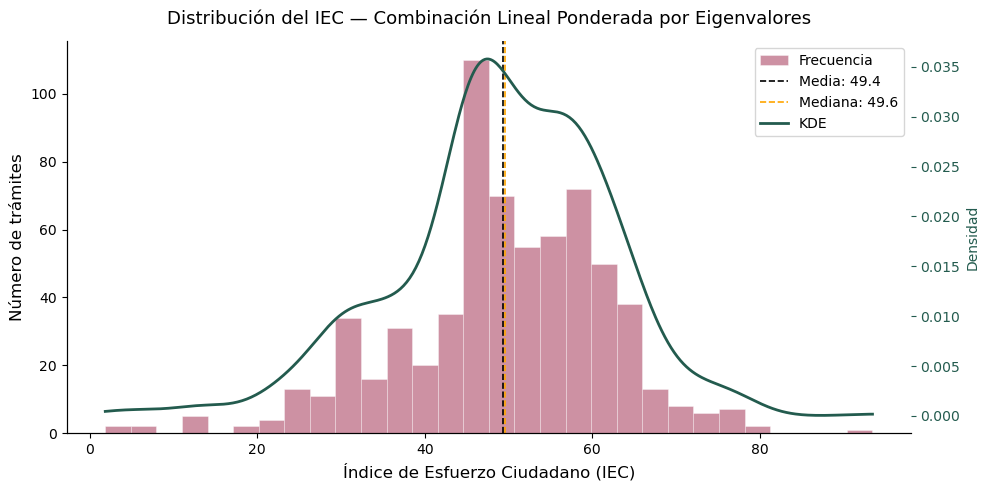

Media:    49.37
Mediana:  49.57
Std:      12.34
Mín:      1.86
Máx:      93.46


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

guinda = '#9D2449'
verde  = '#235B4E'

# Histograma
ax.hist(df['IEC'].dropna(), bins=30, color=guinda, alpha=0.5,
        edgecolor='white', linewidth=0.5, label='Frecuencia')

# KDE superpuesto
iec_vals = df['IEC'].dropna()
kde = gaussian_kde(iec_vals)
x   = np.linspace(iec_vals.min(), iec_vals.max(), 500)
ax2 = ax.twinx()
ax2.plot(x, kde(x), color=verde, linewidth=2, label='KDE')
ax2.set_ylabel('Densidad', color=verde)
ax2.tick_params(axis='y', colors=verde)

# Líneas de referencia
ax.axvline(iec_vals.mean(),   color='black',  linestyle='--', linewidth=1.2, label=f'Media: {iec_vals.mean():.1f}')
ax.axvline(iec_vals.median(), color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {iec_vals.median():.1f}')

ax.set_xlabel('Índice de Esfuerzo Ciudadano (IEC)', fontsize=12)
ax.set_ylabel('Número de trámites', fontsize=12)
ax.set_title('Distribución del IEC — Combinación Lineal Ponderada por Eigenvalores', fontsize=13, pad=12)

# Leyenda combinada
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

print(f'Media:    {iec_vals.mean():.2f}')
print(f'Mediana:  {iec_vals.median():.2f}')
print(f'Std:      {iec_vals.std():.2f}')
print(f'Mín:      {iec_vals.min():.2f}')
print(f'Máx:      {iec_vals.max():.2f}')


<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Conclusiones
</h4>

Los trámites con IEC más alto corresponden principalmente a la **Secretaría de Movilidad y Transporte** y la **Secretaría de Educación Pública**. El trámite con mayor puntuación es *Autorización para Prestar Servicios de Seguridad Privada en el Estado* (93.46), seguido de concesiones y permisos de transporte (78.60) y titulaciones universitarias (77.75).

La **Secretaría de Movilidad y Transporte** encabeza el análisis con el 51.7% de sus trámites por encima del percentil 75 y un índice de concentración de 2.07 — es decir, está sobre-representada en el grupo de IEC alto respecto a su peso en el universo total. Le siguen **Salud** (39.1%) y **Medio Ambiente** (37.5%). La **Secretaría de Gobierno**, aunque no tiene el mayor porcentaje, aporta el mayor volumen absoluto con 36 trámites de IEC alto.

Al comparar los resultados de esta metodología con la Metodología I (Combinación Lineal Ponderada), se identificaron cuatro trámites que aparecen en el top de ambos índices independientemente de los pesos utilizados:

| Trámite | IEC — Metodología I | IEC — Metodología II |
|:--------|:-------------------:|:--------------------:|
| Autorización para Prestar Servicios de Seguridad Privada | 89.7 | **93.46** |
| Opinión favorable para actividades con armas, municiones y explosivos | 75.6 | 71.68 |
| Dictaminación de Avalúos (Catastral) | 70.7 | 72.85 |
| Convocatoria del Instituto de Formación Profesional | 71.5 | 71.68 |

La coincidencia de estos trámites en ambas metodologías sugiere que su alta complejidad es una característica estructural del trámite y no un artefacto de la ponderación utilizada.

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Aspectos a tomar en cuenta
</h4>

**Piso por digitalización:** cualquier trámite completamente presencial obtiene un mínimo de ~29.42 puntos por el sub-índice de digitalización, independientemente de sus demás características. Dado que la mediana de `nivel_digitalizacion` es 1 (presencial), más de la mitad del catálogo parte de ese piso, lo que comprime la discriminación en el rango medio del índice.

**Imputación de tiempo:** los trámites cuyos tiempos fueron imputados con la media global (~22,864 minutos ≈ 16 días) reciben una penalización de $I_Tiempo \approx 71.8$, lo que puede inflar el IEC de trámites que en la realidad son simples. Esto afecta particularmente a servicios de salud como laboratorios clínicos o radiología, cuya aparición en posiciones altas del índice no refleja necesariamente su complejidad real. Una imputación agrupada por secretaría o por tipo de trámite representaría una mejora metodológica relevante.
